# Urban Heat Island — NDVI, Emissivity, LST, UHI Intensity & Heat Exposure Index

**Library:** [`sitex`](../sitex) · **Original, fully-documented version:** [`02-ENV-UHI-analysis.ipynb`](../documentations/02-ENV-UHI-analysis.ipynb)

Thin, parameterized version of the UHI workflow. All the numeric logic lives in
`sitex.env.uhi`; this notebook is the parameters, the calls, and the plots.

**Level-2 only.** Landsat 8/9 Level-1 scenes aren't available for this AOI (a
Global-South-specific USGS ground-station gap), so **LST is read directly from USGS's
own `ST_B10` Surface Temperature band** — already atmospherically corrected with its own
per-pixel emissivity, which also sidesteps a manual mono-window retrieval's known
sensitivity to Vietnam's humid tropical atmosphere. NDVI and Emissivity (NBEM) are still
computed for land-cover narrative — they do **not** feed into LST.

## 1. Install & import

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[env] @ git+https://github.com/ArchiColab/sitex.git"

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[env] @ git+https://github.com/ArchiColab/sitex.git"

    from google.colab import drive
    drive.mount("/content/gdrive")

    DATA_DIR = Path("/content/gdrive/MyDrive/Colab_Outputs")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")

    if not (DATA_DIR / "overture").is_dir():
        raise FileNotFoundError(
            f"{DATA_DIR} not found (or incomplete) in your Google Drive. "
            "Before the workshop: download the workshop data zip and unzip it into "
            "My Drive/Colab_Outputs -- see the workshop setup instructions."
        )
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, display

from sitex.core.raster_viz import colorize_array, hstack_images, save_array_png
from sitex.core.svg_charts import render_bar_chart_svg
from sitex.env import uhi

## 2. Site configuration & scene discovery

Auto-discovers the most recently written `scene_info.json` from
`00-Data-Acquisition_RemoteSensing.ipynb` — the same Phase-1 handoff contract the
original notebook uses. For a manually downloaded EarthExplorer scene instead, use
`uhi.default_bbox()` / `uhi.bbox_to_geojson()` / `uhi.clip_to_geojson()` (see the original
notebook's Section 3).

In [2]:
LOCATION_NAME = "pleiku"
NDVI_THRESHOLD = 0.3

scene_info_path = uhi.find_latest_scene_info(DATA_DIR / "landsat" / "output")
scene_info = uhi.load_scene_info(scene_info_path)
band_paths = uhi.resolve_band_paths(scene_info, scene_info_path)
local_lat, local_lon = scene_info["local_lat"], scene_info["local_lon"]
aoi_geojson = scene_info["aoi_geojson"]
scene_dir = band_paths["B4"].parent

print(f"Scene   : {scene_info['landsat_id']}")
print(f"Level   : {scene_info.get('product_level', 'L2')}")
print(f"AOI     : lat={local_lat}, lon={local_lon}")

Scene   : LC09_L2SP_124050_20260429_02_T1
Level   : L2
AOI     : lat=13.996606232744274, lon=108.03049291070839


## 3. NDVI, Emissivity (NBEM), and LST

NDVI         min=-0.020  max=1.006  mean=0.529
Emissivity   min=0.9277  max=0.9863  mean=0.9857
LST (°C)     min=26.3  max=57.6  mean=44.7


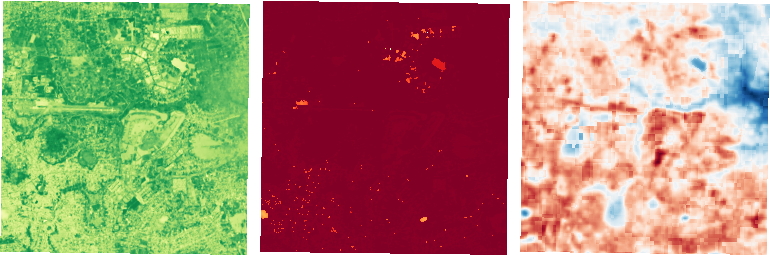

Left to right: NDVI | Emissivity (NBEM, narrative only) | LST (from ST_B10)


In [3]:
ndvi, ndvi_meta = uhi.calc_ndvi(band_paths["B4"], band_paths["B5"], target_path=scene_dir / "ndvi.tif")
emissivity = uhi.calc_emissivity(ndvi, band_paths["B4"], ndvi_meta, target_path=scene_dir / "emissivity.tif")
lst, lst_meta = uhi.calc_lst(band_paths["B10"], target_path=scene_dir / "temperature_lst.tif")

print(f"NDVI         min={np.nanmin(ndvi):.3f}  max={np.nanmax(ndvi):.3f}  mean={np.nanmean(ndvi):.3f}")
print(f"Emissivity   min={np.nanmin(emissivity):.4f}  max={np.nanmax(emissivity):.4f}  mean={np.nanmean(emissivity):.4f}")
print(f"LST (°C)     min={np.nanmin(lst):.1f}  max={np.nanmax(lst):.1f}  mean={np.nanmean(lst):.1f}")

ndvi_png = save_array_png(colorize_array(ndvi, "RdYlGn", vmin=-1, vmax=1), OUTPUT_DIR / "_ndvi.png")
emissivity_png = save_array_png(colorize_array(emissivity, "YlOrRd"), OUTPUT_DIR / "_emissivity.png")
lst_png = save_array_png(colorize_array(lst, "RdBu_r"), OUTPUT_DIR / "_lst.png")
display(Image(str(hstack_images([ndvi_png, emissivity_png, lst_png], OUTPUT_DIR / "_ndvi_emiss_lst.png"))))
print("Left to right: NDVI | Emissivity (NBEM, narrative only) | LST (from ST_B10)")

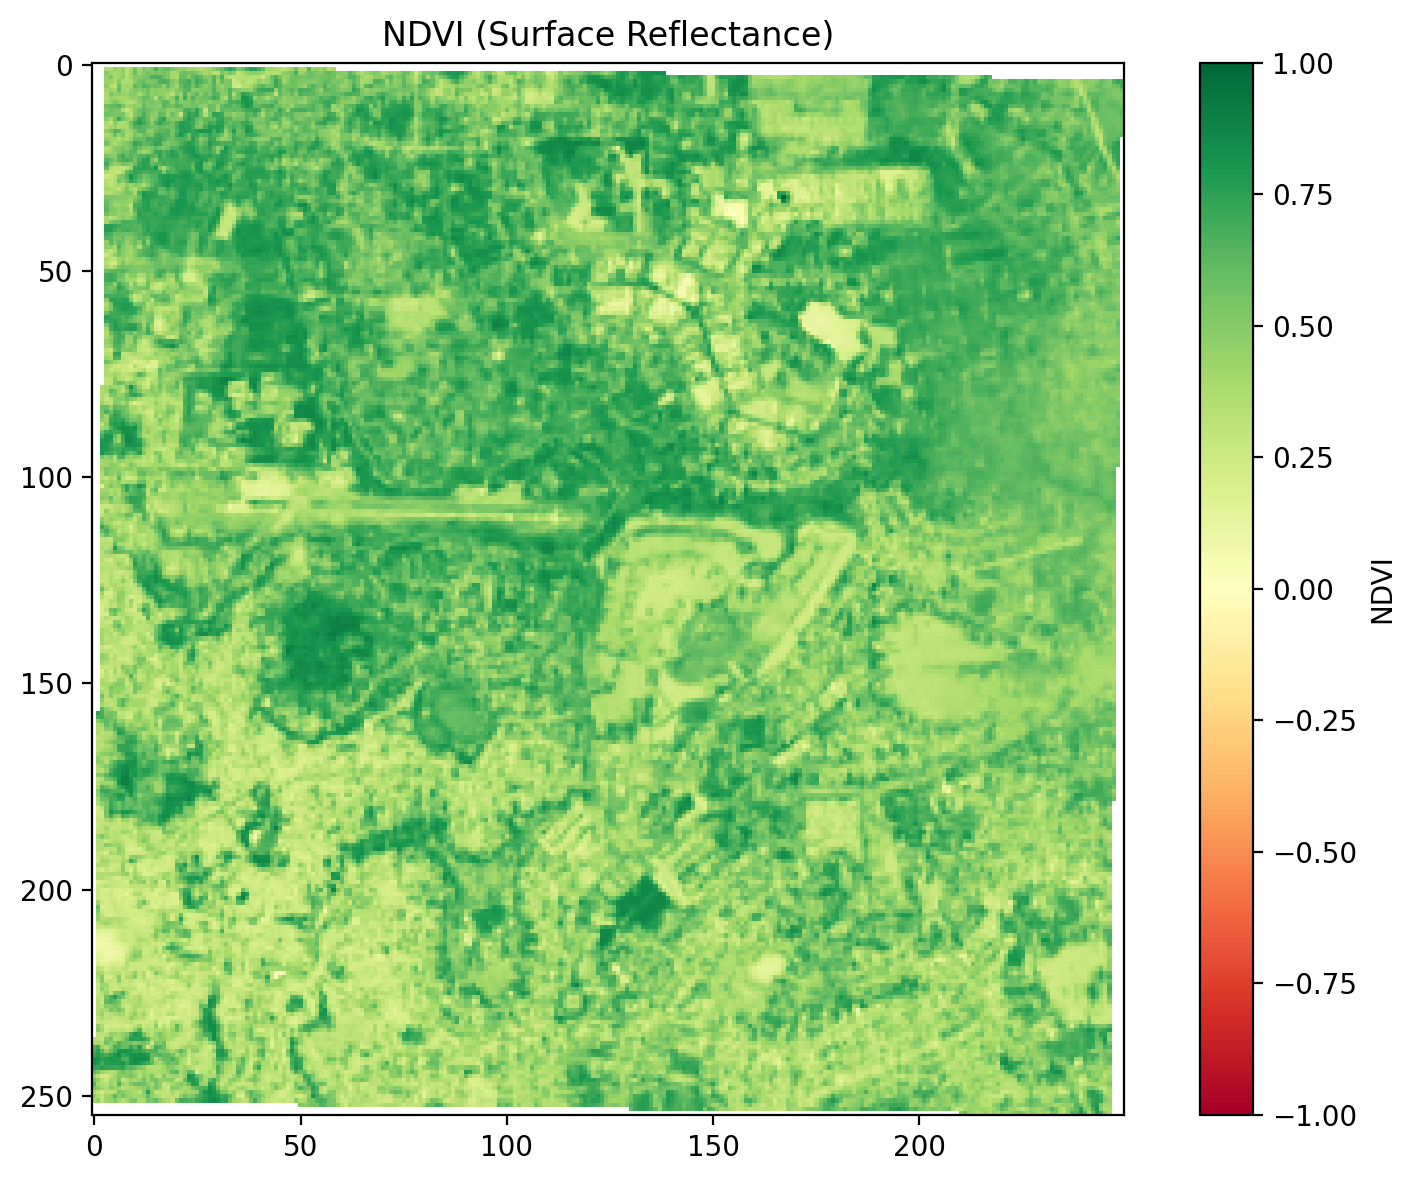

In [4]:
# Plot NDVI
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="NDVI")
ax.set_title(f"NDVI (Surface Reflectance)")
plt.tight_layout()

# plt.show() does nothing under the "Agg" backend (this env's gis kernel crashes on
# the interactive renderer) — save to PNG and display() the file instead.
ndvi_teach_png = OUTPUT_DIR / f"{LOCATION_NAME}_ndvi_teach.png"
fig.savefig(ndvi_teach_png, dpi=200, bbox_inches="tight")
plt.close(fig)
display(Image(str(ndvi_teach_png)))

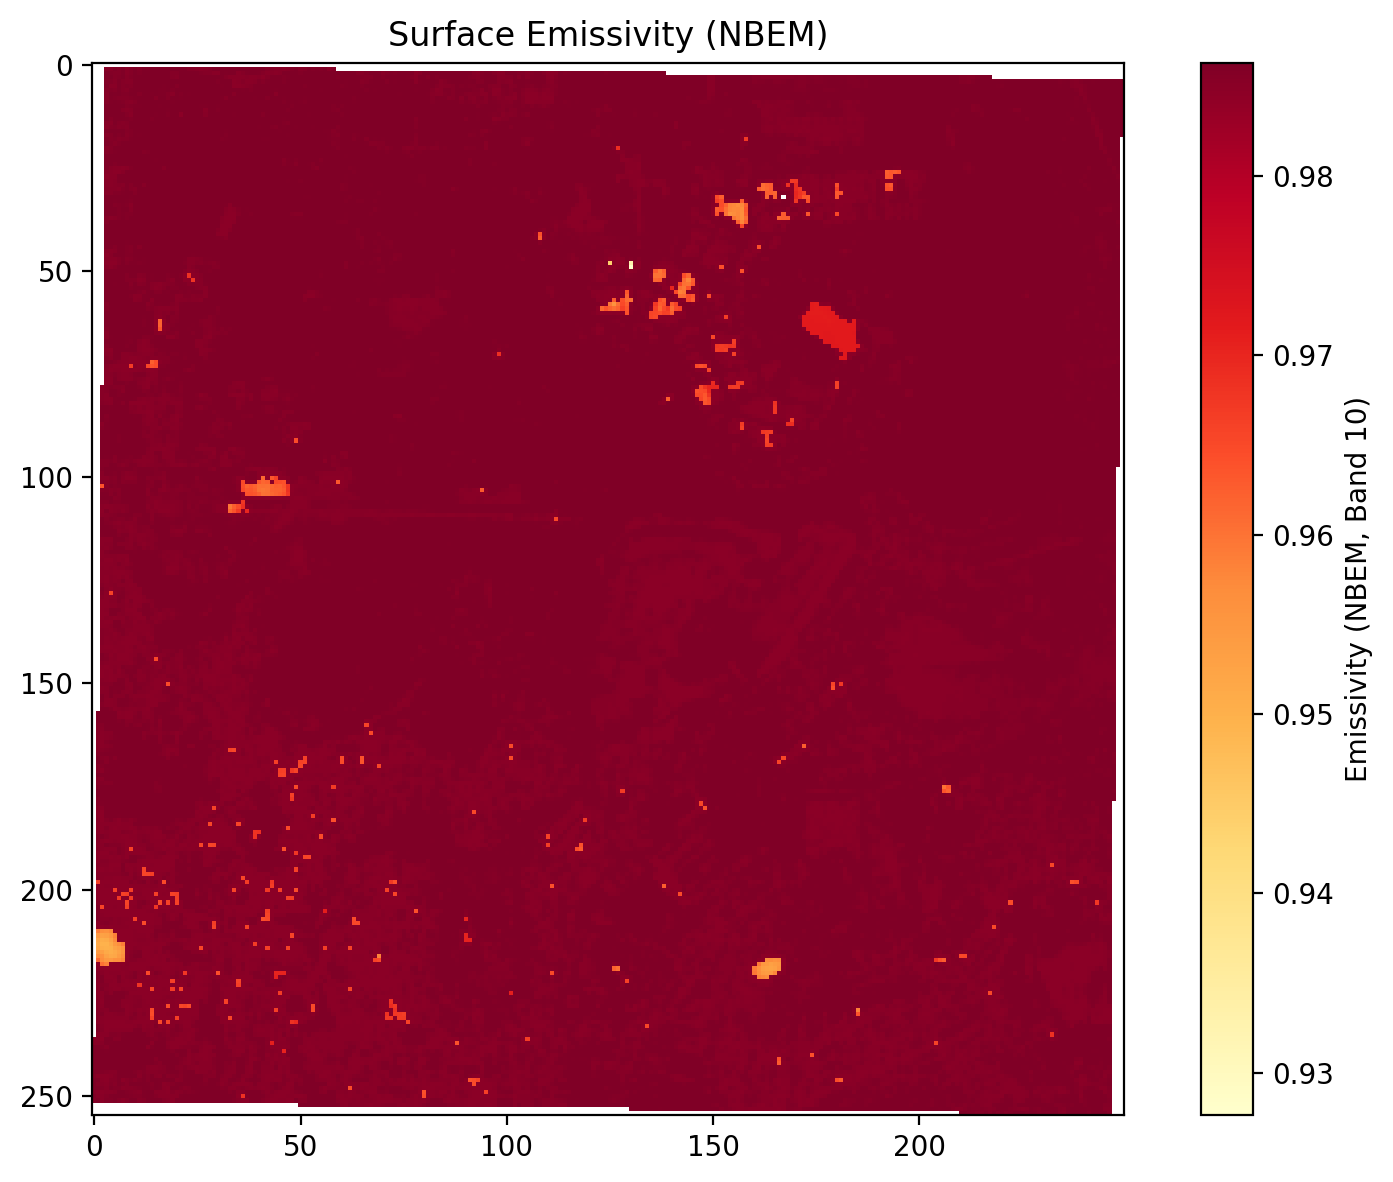

Emissivity  min=0.9277  max=0.9863  mean=0.9857


In [5]:
# Emissivity
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(emissivity, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Emissivity (NBEM, Band 10)")
ax.set_title(f"Surface Emissivity (NBEM)")
plt.tight_layout()

# plt.show() does nothing under the "Agg" backend (this env's gis kernel crashes on
# the interactive renderer) — save to PNG and display() the file instead.
emissivity_teach_png = OUTPUT_DIR / f"{LOCATION_NAME}_emissivity_teach.png"
fig.savefig(emissivity_teach_png, dpi=200, bbox_inches="tight")
plt.close(fig)
display(Image(str(emissivity_teach_png)))

print(
    f"Emissivity  min={np.nanmin(emissivity):.4f}  max={np.nanmax(emissivity):.4f}  "
    f"mean={np.nanmean(emissivity):.4f}"
)

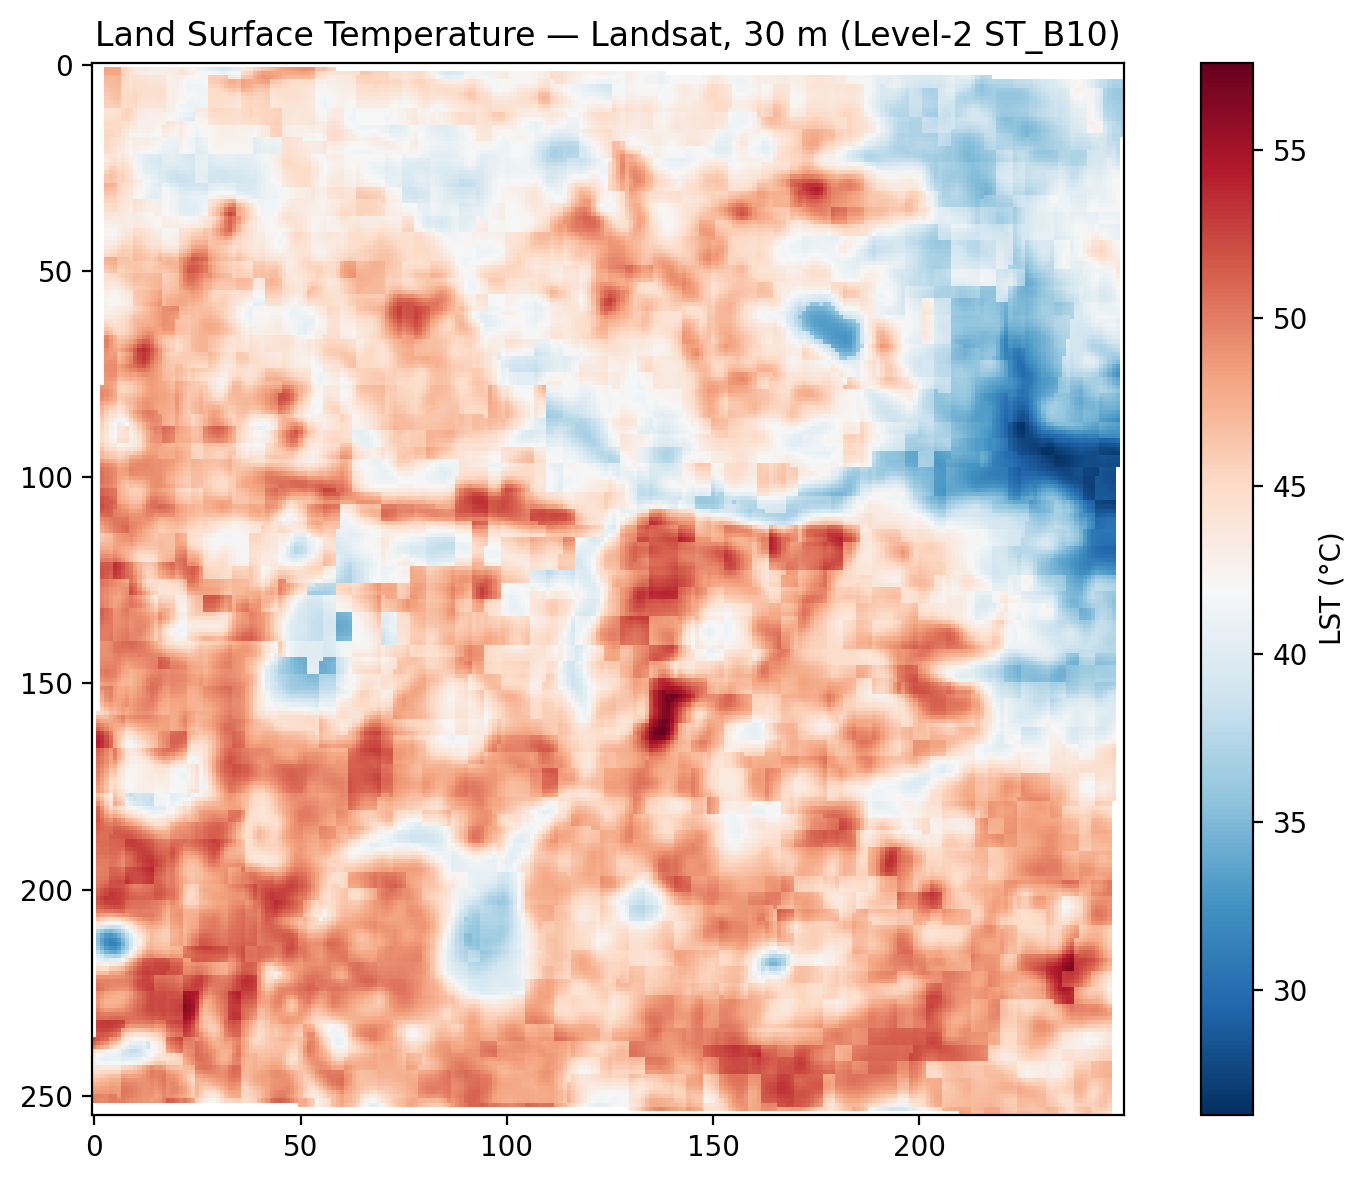

LST (Landsat, 30 m)  min=26.3°C  max=57.6°C  mean=44.7°C


In [6]:
#Land Surface Temperature
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(lst, cmap="RdBu_r")
plt.colorbar(im, ax=ax, label="LST (°C)")
ax.set_title(f"Land Surface Temperature — Landsat, 30 m (Level-2 ST_B10)")
plt.tight_layout()

# plt.show() does nothing under the "Agg" backend (this env's gis kernel crashes on
# the interactive renderer) — save to PNG and display() the file instead.
lst_teach_png = OUTPUT_DIR / f"{LOCATION_NAME}_lst_teach.png"
fig.savefig(lst_teach_png, dpi=200, bbox_inches="tight")
plt.close(fig)
display(Image(str(lst_teach_png)))

print(f"LST (Landsat, 30 m)  min={np.nanmin(lst):.1f}°C  max={np.nanmax(lst):.1f}°C  mean={np.nanmean(lst):.1f}°C")

## 4. UHI intensity — vegetated vs. built-up temperature gap

NDVI as a cheap land-cover proxy (no segmentation model needed): the mean-LST gap
between vegetated and built-up/bare pixels is the classic Surface UHI intensity
indicator, at the native 30 m resolution.

In [7]:
result = uhi.compute_uhi_intensity(ndvi, lst, ndvi_threshold=NDVI_THRESHOLD)

print(f"NDVI threshold                 : {result['ndvi_threshold']}")
print(f"Vegetated area                 : {result['vegetation_pct']:.1f}% of AOI")
print(f"Mean LST - vegetated pixels    : {result['mean_lst_vegetation']:.1f} °C")
print(f"Mean LST - built-up/bare pixels: {result['mean_lst_built_up']:.1f} °C")
print(f"Estimated Surface UHI intensity: {result['uhi_intensity']:.1f} °C  (built-up minus vegetated)")


NDVI threshold                 : 0.3
Vegetated area                 : 87.5% of AOI
Mean LST - vegetated pixels    : 44.2 °C
Mean LST - built-up/bare pixels: 48.6 °C
Estimated Surface UHI intensity: 4.4 °C  (built-up minus vegetated)


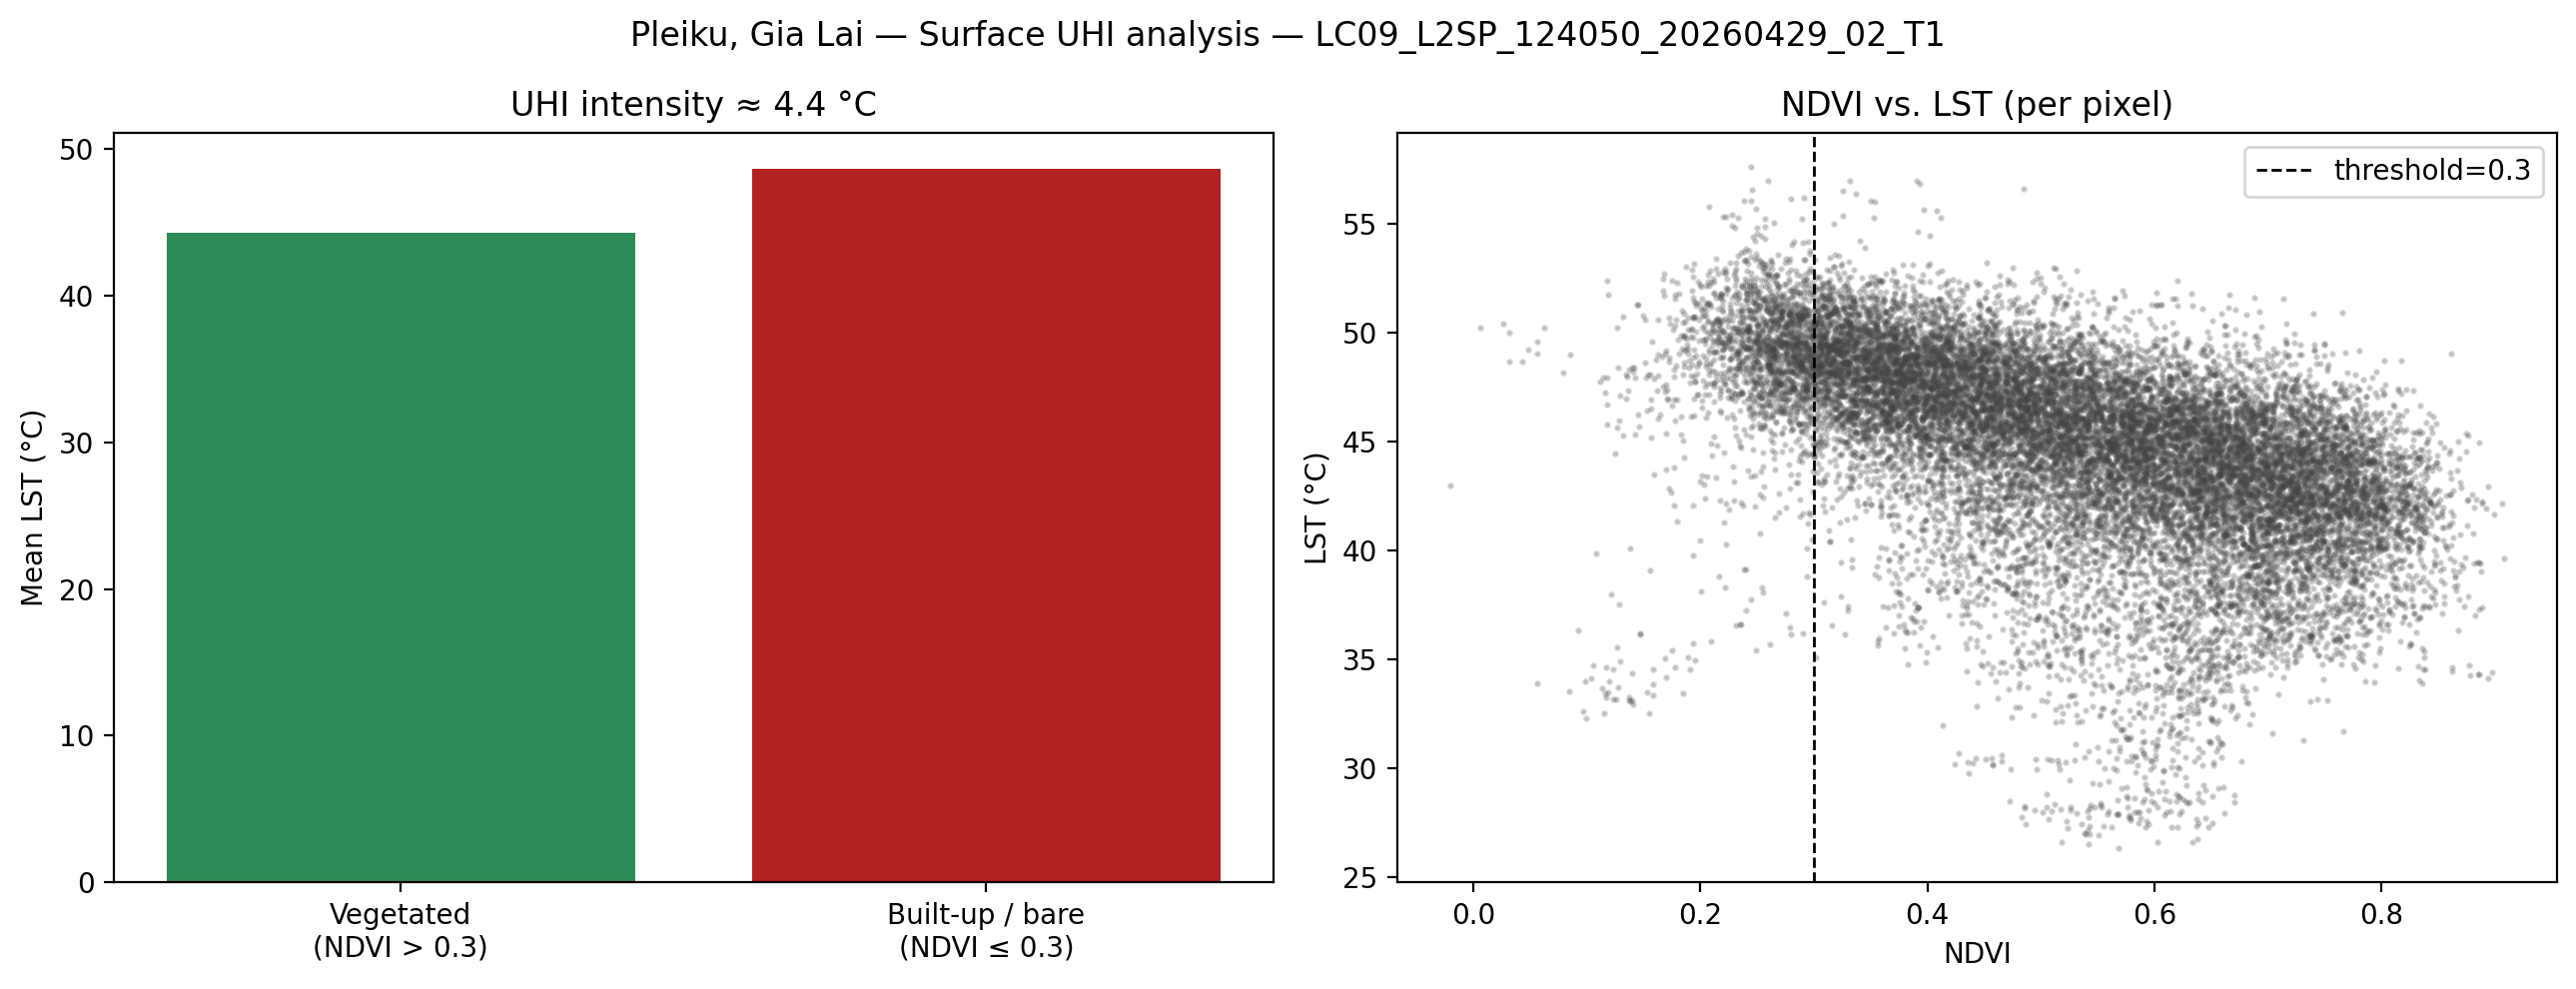

Static summary figure saved to: ..\..\outputs\pleiku_uhi_summary.png


In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    [f"Vegetated\n(NDVI > {NDVI_THRESHOLD})", f"Built-up / bare\n(NDVI ≤ {NDVI_THRESHOLD})"],
    [result["mean_lst_vegetation"], result["mean_lst_built_up"]],
    color=["#2e8b57", "#b22222"],
)
axes[0].set_ylabel("Mean LST (°C)")
axes[0].set_title(f"UHI intensity ≈ {result['uhi_intensity']:.1f} °C")

rng = np.random.default_rng(42)
flat_ndvi, flat_lst = ndvi.ravel(), lst.ravel()
valid = np.isfinite(flat_ndvi) & np.isfinite(flat_lst)
sample_idx = rng.choice(np.flatnonzero(valid), size=min(20000, valid.sum()), replace=False)

axes[1].scatter(flat_ndvi[sample_idx], flat_lst[sample_idx], s=2, alpha=0.2, color="#444")
axes[1].axvline(NDVI_THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"threshold={NDVI_THRESHOLD}")
axes[1].set_xlabel("NDVI")
axes[1].set_ylabel("LST (°C)")
axes[1].set_title("NDVI vs. LST (per pixel)")
axes[1].legend()

fig.suptitle(f"Pleiku, Gia Lai — Surface UHI analysis — {scene_info['landsat_id']}", fontsize=12)
plt.tight_layout()

uhi_summary_png = OUTPUT_DIR / f"{LOCATION_NAME}_uhi_summary.png"
fig.savefig(uhi_summary_png, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(str(uhi_summary_png)))
print(f"Static summary figure saved to: {uhi_summary_png}")

## 5. Heat Exposure Index (HEI)

A composite of normalized LST (thermal load) and vegetation deficit (`1 - normalized NDVI`) 
into a single 0–1 map at native 30 m resolution. 

HEI is tested at three weighting scenarios rather than committing to
one. Equal weighting (50/50) is the primary/exported scenario; 70/30 and 30/70 are a
sensitivity check. If a pixel is ranked as “high‑priority” no matter how you weight the 
two inputs (LST vs vegetation deficit), then that pixel is a reliable hotspot, not just 
a hotspot under one specific formula.


**Step 1 — normalize both layers to [0, 1]:**

$$
LST_{norm} = \frac{LST - LST_{min}}{LST_{max} - LST_{min}}
\qquad\qquad
NDVI_{norm} = \frac{NDVI - NDVI_{min}}{NDVI_{max} - NDVI_{min}}
$$

**Step 2 — invert NDVI into a "vegetation deficit"** (low NDVI = little vegetation = higher
heat-mitigation priority):

$$
VegDeficit = 1 - NDVI_{norm}
$$

**Step 3 — weighted composite**, tested at three weighting scenarios rather than committing to a
single one:

$$
HEI_{50/50} = 0.5\,LST_{norm} + 0.5\,VegDeficit
\qquad
HEI_{70/30} = 0.7\,LST_{norm} + 0.3\,VegDeficit
\qquad
HEI_{30/70} = 0.3\,LST_{norm} + 0.7\,VegDeficit
$$

Equal weighting (50/50) is the notebook's default/exported scenario — a defensible choice when
there isn't empirical evidence to rate one factor over the other (Bao, Li & Yu, 2015). The 70/30
and 30/70 scenarios show how sensitive the priority map is to that choice. The pixels that stay
high-priority across all three are the more robust hot spots; pixels that swing with the weighting
are worth flagging separately. This composite-indicator, equal/unequal-weight approach is common in
heat-vulnerability indices generally, e.g. the Global Urban Heat Vulnerability Index (Turner et al.,
2025).

This is a **proposed screening indicator**, not a validated measure of actual human heat exposure —
useful for ranking areas within this AOI, not for comparison against other studies' HEI values.

> Bao, J., Li, X., & Yu, C. (2015). The Construction and Validation of the Heat Vulnerability
> Index, a Review. *International Journal of Environmental Research and Public Health*, 12(7),
> 7220–7234. https://doi.org/10.3390/ijerph120707220
>
> Turner, R., Higgs, C., Sun, C., et al. (2025). Development and validation of the Global Urban
> Heat Vulnerability Index (GUHVI). *Urban Climate*, 64, 102716.
> https://doi.org/10.1016/j.uclim.2025.102716

In [9]:
hei_arrays = uhi.compute_hei(lst, ndvi)
hei_paths = uhi.export_hei_geotiffs(hei_arrays, ndvi_meta, scene_dir)

for label, array in hei_arrays.items():
    print(f"HEI {label.replace('_', '/')}  min={np.nanmin(array):.3f}  max={np.nanmax(array):.3f}  "
          f"mean={np.nanmean(array):.3f}  -> {hei_paths[label]}")

sensitivity = uhi.hei_sensitivity_range(hei_arrays)
print(f"\nHEI range across scenarios  mean={np.nanmean(sensitivity):.3f}  max={np.nanmax(sensitivity):.3f}")

HEI_PRIMARY = "50_50"
hei = hei_arrays[HEI_PRIMARY]
file_hei = hei_paths[HEI_PRIMARY]

HEI 50/50  min=0.176  max=0.883  mean=0.526  -> ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_50_50.tif
HEI 70/30  min=0.114  max=0.924  mean=0.550  -> ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_70_30.tif
HEI 30/70  min=0.148  max=0.911  mean=0.501  -> ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_30_70.tif

HEI range across scenarios  mean=0.064  max=0.286


C:\Users\Maddie\OneDrive\000_CIC2025\CIC2025\100 Lab Notes\Projects\CIC2025 Masterthesis\Experiments\sitex\src\sitex\env\uhi.py:288: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(stack, axis=0) - np.nanmin(stack, axis=0)


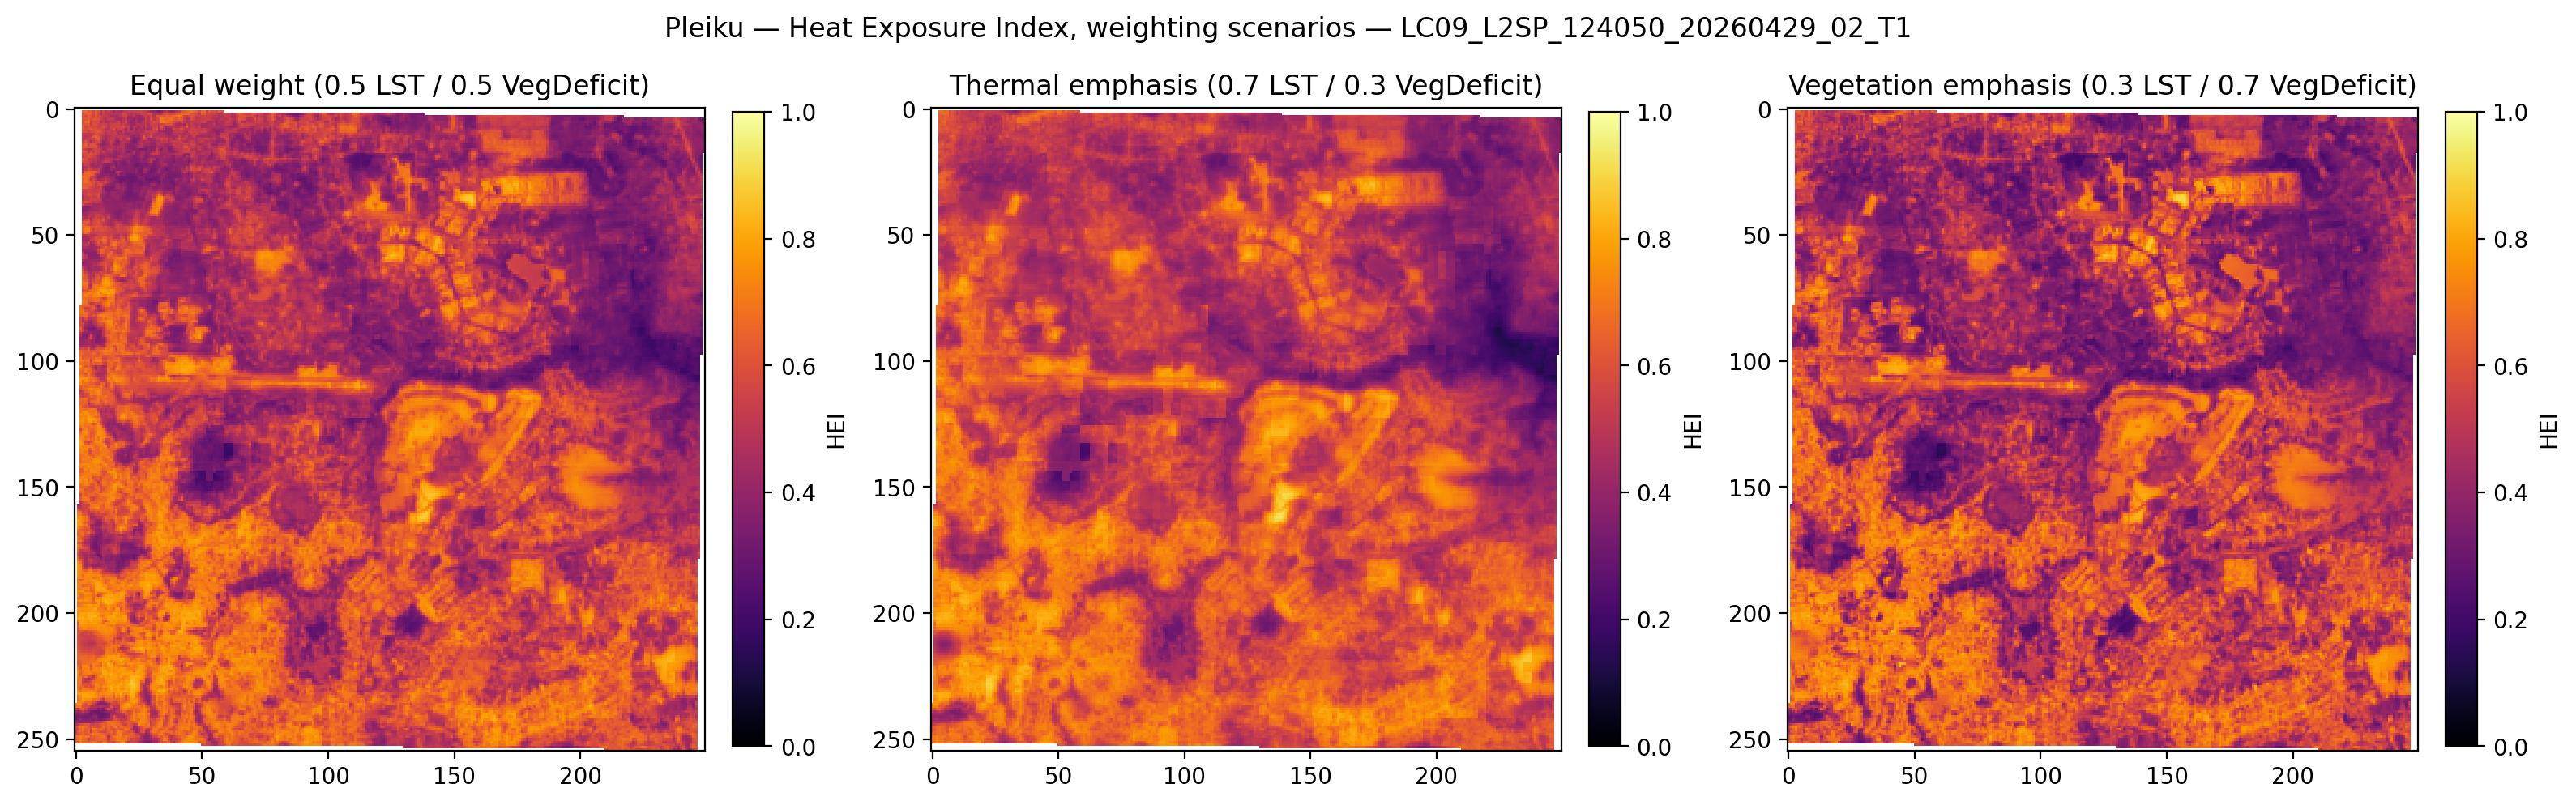

HEI scenarios figure saved to: ..\..\outputs\pleiku_hei_scenarios.png


In [10]:
# Agg backend + savefig + display()to avoid the interactive-render kernel crash.

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

HEI_TITLES = {
    "50_50": "Equal weight (0.5 LST / 0.5 VegDeficit)",
    "70_30": "Thermal emphasis (0.7 LST / 0.3 VegDeficit)",
    "30_70": "Vegetation emphasis (0.3 LST / 0.7 VegDeficit)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, label in zip(axes, uhi.HEI_WEIGHTS):
    im = ax.imshow(hei_arrays[label], cmap="inferno", vmin=0, vmax=1)
    ax.set_title(HEI_TITLES[label])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="HEI")
fig.suptitle(f"Pleiku — Heat Exposure Index, weighting scenarios — {scene_info['landsat_id']}", fontsize=12)
plt.tight_layout()

hei_scenarios_png = OUTPUT_DIR / f"{LOCATION_NAME}_hei_scenarios.png"
fig.savefig(hei_scenarios_png, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(str(hei_scenarios_png)))
print(f"HEI scenarios figure saved to: {hei_scenarios_png}")

## 6. Reproject & colorize for the webmap

In [11]:
file_ndvi_repr = uhi.reproject_geotiff(scene_dir / "ndvi.tif", scene_dir / "ndvi_reprojected.tif", 4326)
file_lst_repr = uhi.reproject_geotiff(scene_dir / "temperature_lst.tif", scene_dir / "temperature_lst_reprojected.tif", 4326)
file_emissivity_repr = uhi.reproject_geotiff(scene_dir / "emissivity.tif", scene_dir / "emissivity_reprojected.tif", 4326)
file_hei_repr = uhi.reproject_geotiff(file_hei, scene_dir / f"hei_{HEI_PRIMARY}_reprojected.tif", 4326)

_, ndvi_rgba = uhi.create_rgba_color_image(file_ndvi_repr, scene_dir / "ndvi_reprojected_colored.tif", "RdYlGn")
_, lst_rgba = uhi.create_rgba_color_image(file_lst_repr, scene_dir / "temperature_lst_reprojected_colored.tif", "RdBu_r")
_, emissivity_rgba = uhi.create_rgba_color_image(file_emissivity_repr, scene_dir / "emissivity_reprojected_colored.tif", "YlOrRd")
_, hei_rgba = uhi.create_rgba_color_image(file_hei_repr, scene_dir / f"hei_{HEI_PRIMARY}_reprojected_colored.tif", "inferno")

print("Reprojected + colorized: NDVI, LST, Emissivity, HEI")

Reprojected + colorized: NDVI, LST, Emissivity, HEI


## 7. Interactive webmap

Webmap saved to: ..\..\outputs\pleiku_uhi_webmap.html



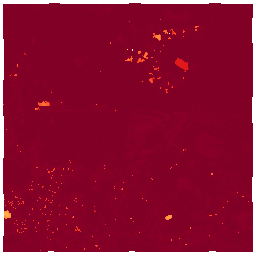
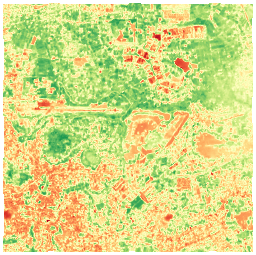
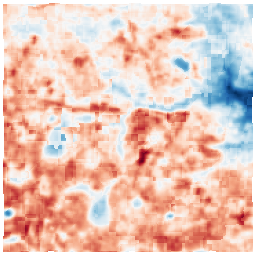
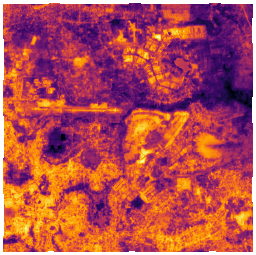

In [12]:
_, ndvi_bounds = uhi.load_raster_rgba(scene_dir / "ndvi_reprojected_colored.tif")
_, lst_bounds = uhi.load_raster_rgba(scene_dir / "temperature_lst_reprojected_colored.tif")
_, emissivity_bounds = uhi.load_raster_rgba(scene_dir / "emissivity_reprojected_colored.tif")
_, hei_bounds = uhi.load_raster_rgba(scene_dir / f"hei_{HEI_PRIMARY}_reprojected_colored.tif")

webmap = uhi.build_uhi_webmap(
    center=(local_lat, local_lon),
    layers={
        "Emissivity": (emissivity_rgba, emissivity_bounds),
        "NDVI": (ndvi_rgba, ndvi_bounds),
        "Land Surface Temperature": (lst_rgba, lst_bounds),
        f"Heat Exposure Index ({HEI_PRIMARY.replace('_', '/')})": (hei_rgba, hei_bounds),
    },
    aoi_geojson=aoi_geojson,
    primary=f"Heat Exposure Index ({HEI_PRIMARY.replace('_', '/')})",
)

webmap_path = OUTPUT_DIR / f"{LOCATION_NAME}_uhi_webmap.html"
webmap.save(str(webmap_path))
print(f"Webmap saved to: {webmap_path}")
webmap

## 8. Summary

In [13]:
print("Outputs for this run:")
print(f"  Landsat scene            : {scene_info['landsat_id']}")
print(f"  Surface UHI intensity    : {result['uhi_intensity']:.1f} °C (built-up minus vegetated, 30 m)")
print(f"  Heat Exposure Index      : {HEI_PRIMARY.replace('_', '/')} (primary)")
print(f"  HEI GeoTIFFs             : {', '.join(str(p) for p in hei_paths.values())}")
print(f"  HEI scenarios image      : {hei_scenarios_png}")
print(f"  Interactive webmap (HTML): {webmap_path}")

Outputs for this run:
  Landsat scene            : LC09_L2SP_124050_20260429_02_T1
  Surface UHI intensity    : 4.4 °C (built-up minus vegetated, 30 m)
  Heat Exposure Index      : 50/50 (primary)
  HEI GeoTIFFs             : ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_50_50.tif, ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_70_30.tif, ..\..\data\landsat\output\LC09_L2SP_124050_20260429_02_T1\hei_30_70.tif
  HEI scenarios image      : ..\..\outputs\pleiku_hei_scenarios.png
  Interactive webmap (HTML): ..\..\outputs\pleiku_uhi_webmap.html


---
## Notes

- **HEI is a proposed screening indicator, not a validated measure of human heat
  exposure** — useful for ranking areas within this AOI, not for comparison against
  other studies' HEI values.
- **This module reads directly from `scene_info.json`'s own directory**
  (`uhi.resolve_band_paths`), not the path strings stored inside it — those were written
  relative to wherever the acquisition notebook happened to run from, which breaks the
  moment this notebook is opened from a different working directory.
- **Plots here go through `sitex.core.raster_viz`/`svg_charts`, not matplotlib
  `imshow`/`bar`/`scatter`, on purpose** — this project's `gis` conda environment
  crashes the kernel on any actual matplotlib figure render, independent of what's
  plotted. See `sitex.core.raster_viz`'s module docstring, and
  `01-ARCH-POIsClassification.ipynb`'s own hand-built-SVG chart for the same issue found
  earlier in this project.
- The NDVI-vs-LST relationship is shown as a density heatmap (Section 4) rather than the
  original's ~20,000-point scatter, for the same reason — and arguably reads more
  clearly at this point count regardless.
- To run against a specific (not "latest") scene, or a manually downloaded EarthExplorer
  scene, replace Section 2 with an explicit `scene_info_path`, or use
  `uhi.default_bbox()`/`uhi.bbox_to_geojson()`/`uhi.clip_to_geojson()` directly — see the
  original notebook's Section 3.